## This notebook uses RDMC to generate initial TS guess from user-provided atom-mapped reaction smiles

### currently implemented for bi-molecular H abstraction reactions

todo:

In [1]:
import re
import json

from rdmc import RDKitMol
from rdmc.view import ts_viewer

from rdmc.forcefield import RDKitFF

import numpy as np
import json
import copy

from QuantumPioneer import utils as qp_utils
import QuantumPioneer as qp

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
# useful if you are opening this notebook in a browser
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# Function to generate a bi-habs TS example
# Use R1H + R2OO* = R1* + R2OOH as demo

In [3]:
# Empirical parameters
EMPIRICAL_PARA_TS_GUESS = {
        'angle_X_H_Y': 160, # initial angle for TS pivot. Do not make it too close to 180.
        'dihedral_r1': 0, # initial dihedral angle for TS, defined using r1, does not really matter most of the time for bi-molecular H abstraction.
        'dihedral_r2': 0, # the other diehdral angle, defined using reactant 2 or r2
        'bond_length_scale_factor_r1': 1.22, # how much to scale the TS bond length based on reactant bond length for r1; can be modified to scale each bond differently, but usually 1.2-1.25 is good guess for bi-molecular H abstraction with C-H and 1.15 - 1.2 for O-H.
        'bond_length_scale_factor_r2': 1.19, # how much to scale the TS bond length based on reactant bond length for r1; can be modified to scale each bond differently, but usually 1.2-1.25 is good guess for bi-molecular H abstraction with C-H and 1.15 - 1.2 for O-H.
        'bond_length_X_H': None, # directly specifiy the TS bond length for r1, useful if another bond length estimater e.g., TS-EGNN/Chemprop/Kinbot can provide this information
        'bond_length_H_Y': None, # directly specifiy the TS bond length for r2
}

In [4]:
zero_idx_smi = '[H:10][C:15]([H:11])([H:12])[C:16]([H:13])([H:14])[F:17].[H:0][C:5]([H:1])([H:2])[S:9][C:6]([H:3])([H:4])[O:8][O:7]>>[H:11][C:15]([H:12])[C:16]([H:13])([H:14])[F:17].[H:0][C:5]([H:1])([H:2])[S:9][C:6]([H:3])([H:4])[O:8][O:7][H:10]'
one_idx_smi = '[H:11][C:16]([H:12])([H:13])[C:17]([H:14])([H:15])[F:18].[H:1][C:6]([H:2])([H:3])[S:10][C:7]([H:4])([H:5])[O:9][O:8]>>[H:12][C:16]([H:13])[C:17]([H:14])([H:15])[F:18].[H:1][C:6]([H:2])([H:3])[S:10][C:7]([H:4])([H:5])[O:9][O:8][H:11]'

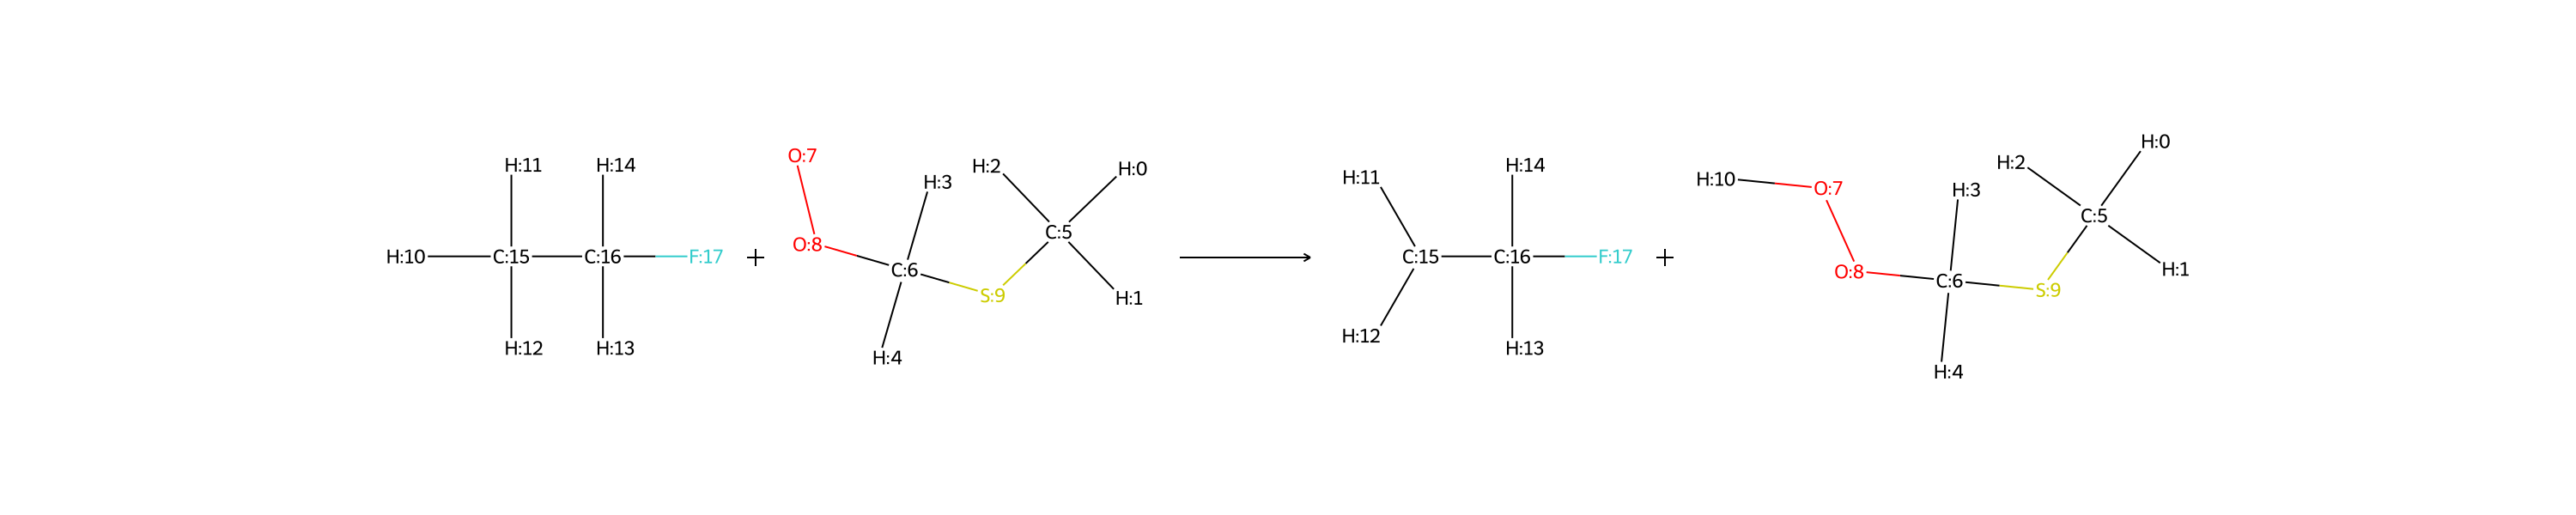

In [5]:
from rdkit.Chem import Draw
from rdkit.Chem import rdChemReactions as Reactions

rxn = Reactions.ReactionFromSmarts(zero_idx_smi, useSmiles=True)
Draw.ReactionToImage(rxn, subImgSize=(600, 600))


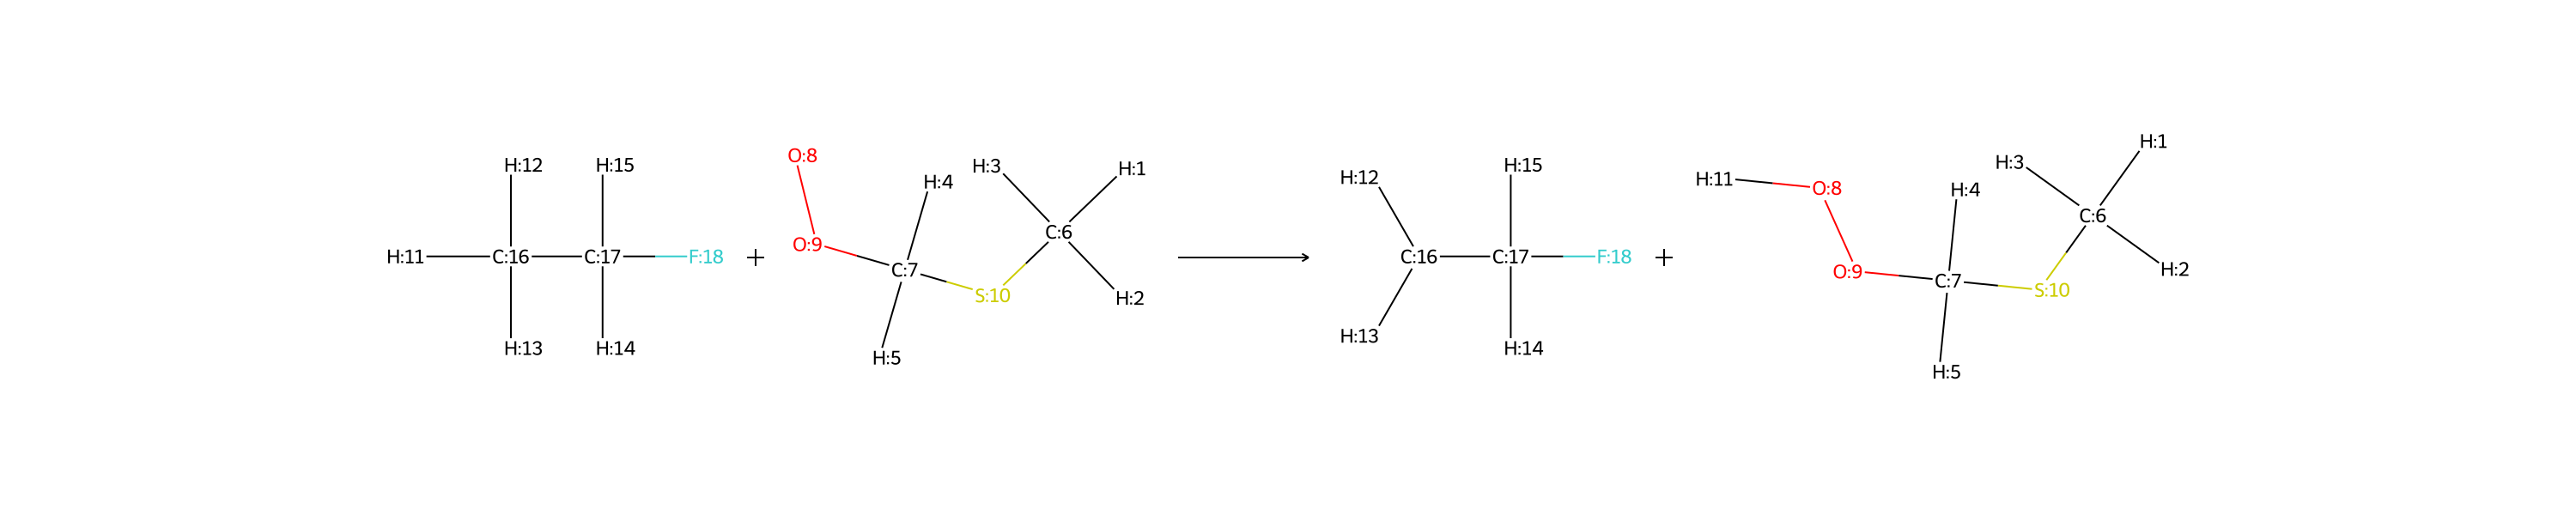

In [6]:
rxn = Reactions.ReactionFromSmarts(one_idx_smi, useSmiles=True)
Draw.ReactionToImage(rxn, subImgSize=(600, 600))

In [7]:
rxn = qp.BimolecularHydrogenAbstractionReaction(zero_idx_smi)
rxn

In [8]:
output = rxn.gen_n_ts_confs(
           num_confs = 50,
           max_total_iter = 50,
)

In [9]:
# write to json file
with open("ts_guess.json", "w") as outfile:
    json.dump(output, outfile)

In [10]:
def xyz_string_to_np_array(input_str):
    # Using a regular expression to extract all floating point numbers from the string
    numbers = re.findall(r"[-+]?\d*\.\d+|\d+", input_str)

    # Converting the list of strings to a list of floats
    numbers = [float(num) for num in numbers]

    # Reshaping the list into an array of shape (N, 3), where N is the number of atoms
    return np.array(numbers).reshape(-1, 3)

In [11]:
def reconstruct_complex(rxn_smi, fbond, ts_xyz_str=None):
    """
    This function reconstruct r_complex, p_complex, and ts_complex from atom-mapped
    reaction smiles.
    """

    r_complex, p_complex = [RDKitMol.FromSmiles(smi) for smi in rxn_smi.split(">>")]

    # here we use ETKDGv3() defined on top of the notebook, but can be changed to
    # others if needed
    r_complex.EmbedConformer(qp_utils.FF)
    p_complex.EmbedConformer(qp_utils.FF)

    # we need to add redundant bond to the reactant complex graph to represent the
    # TS geometry
    ts_complex = r_complex.AddRedundantBonds(fbond)

    if ts_xyz_str:
        ts_xyz_array = xyz_string_to_np_array(ts_xyz_str)
        ts_complex.SetPositions(ts_xyz_array)

    return r_complex, p_complex, ts_complex

In [12]:
r_complex, p_complex, ts_complex = reconstruct_complex(
    rxn_smi=output['rxn_smi'],
    fbond=output['formed_bond'],
    ts_xyz_str=output['ts_conformers_coord'][0][-1]
)

In [13]:
ts_viewer(r_complex, p_complex, ts_complex, only_ts=True)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [14]:
r_complex, p_complex, ts_complex = reconstruct_complex(
    rxn_smi=output['rxn_smi'],
    fbond=output['formed_bond'],
    ts_xyz_str=output['ts_conformers_coord'][-1][-1]
)

In [15]:
ts_viewer(r_complex, p_complex, ts_complex, only_ts=True)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.